<a href="https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

Primary Lane: Lane 2 - Refresh/Opportunity Scoring
What if we are able to run a diagnostic test and find underperforming pages and plausible reasons to explain areas that can be improved?
This work incorporates a visibility scoring system comprising of reach and quality components computed using observable content and search signals.

Why it matters?
Agencies and businesses spend time trying to analyse web pages and what may boost ranking. Sometimes, it is the content length, other times it could be freshness or the intent. While there is no one-size fit all for all web pages, it would be easier to run a diagnostic test to determine what page is underperforming their potential and what may be the cause of it, giving the agencies or businesses opportunities to prioritze those pages for refresh.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/content_refresh_anonymized.csv')
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [4]:
for i in df.columns:
  print(df[i].value_counts())
  print(len(df[i]))
  print()

content_id
content_6880eb215048    1
content_fe5d259e6bc5    1
content_2dfd17269502    1
content_81a91fe32bc2    1
content_6f2f3043b633    1
                       ..
content_d99b7a2d90ca    1
content_331d6c4de07b    1
content_9aa793d4d895    1
content_a1fb4e703a9e    1
content_304f48230142    1
Name: count, Length: 30000, dtype: int64
30000

client_id
client_19581e27de    7008
client_6208ef0f77    3681
client_4e07408562    2294
client_3fdba35f04    2267
client_f369cb89fc    1796
client_8527a891e2    1194
client_a88a7902cb    1171
client_d4735e3a26    1106
client_7f2253d7e2    1043
client_f74efabef1    1031
client_d029fa3a95     952
client_349c41201b     763
client_e629fa6598     720
client_e29c9c180c     708
client_2c624232cd     649
client_8722616204     578
client_4ec9599fc2     556
client_bbb965ab0c     505
client_25fc0e7096     476
client_624b60c58c     337
client_9f14025af0     325
client_b4944c6ff0     254
client_9400f1b21c     158
client_98a3ab7c34     118
client_434c9b5ae5    

To create a scoring system, we would have to do so relative to the peer group. This is because it is only meaningful to compare contents of the same group. We would work with informational content in this context.

In [13]:
info_data = df[df['main_intent'] == 'informational'].copy()
info_data

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7
6,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,15000-25000,0.00,7.0,0.00,0.00,0.0,low,page_1,down,-92.3
8,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,15000-25000,0.09,46.0,5.88,6.25,0.0,excellent,page_3_5,down,-58.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29988,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,keyword article,informational,1446.0,9001.0,...,8000-15000,0.00,54.0,0.00,0.00,0.0,low,deep,down,-100.0
29989,content_e859812ce999,client_19581e27de,10.0,0.20,LOW,0.00,keyword article,informational,NaN,NaN,...,NaN,0.05,6.1,8.70,7.69,0.0,good,page_1,down,-35.2
29990,content_b7fa2d76e5ae,client_4e07408562,70.0,0.00,LOW,0.00,keyword article,informational,2501.0,15617.0,...,15000-25000,0.16,22.5,0.00,0.00,0.0,moderate,page_3_5,stable,-17.8
29992,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,keyword article,informational,1508.0,9735.0,...,8000-15000,0.00,0.0,0.00,0.00,0.0,low,top_3,new,NaN


In [6]:
info_data.iloc[0]

,1
content_id,content_a1fb4e703a9e
client_id,client_4e07408562
search_volume,90.0
competition,0.01
competition_level,LOW
cpc,0.05
content_type,keyword article
main_intent,informational
word_count,2481.0
char_count,15562.0


In [8]:
info_data.info()

for i in info_data.columns:
  print(i)
  print()
  print(info_data[i].describe())
  print()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   main_intent             17235 non-null  object 
 8   word_count              13169 non-null  float64
 9   char_count              13169 non-null  float64
 10  provider_used           5399 non-null   object 
 11  model_used              14443 non-null  object 
 12  impressions_90d         17235 non-null  int64  
 13  clicks_90d              17235 non-null  int64  
 14  pageviews_90d           17235 non-null  int

In [14]:
to_drop = []

for i in info_data.columns:
  if 'tier' in i:
    to_drop.append(i)
to_drop

['age_tier',
 'age_tier_order',
 'freshness_tier',
 'word_count_tier',
 'char_count_tier',
 'impression_tier',
 'position_tier']

In [15]:
info_data = info_data.drop(columns = to_drop, axis = 1)
info_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   main_intent             17235 non-null  object 
 8   word_count              13169 non-null  float64
 9   char_count              13169 non-null  float64
 10  provider_used           5399 non-null   object 
 11  model_used              14443 non-null  object 
 12  impressions_90d         17235 non-null  int64  
 13  clicks_90d              17235 non-null  int64  
 14  pageviews_90d           17235 non-null  int

In [16]:
info_data.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days',
       'days_since_last_update', 'ctr', 'avg_position', 'engagement_rate',
       'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct'],
      dtype='object')

In [27]:
performance_columns = ['impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d','ctr', 'avg_position', 'engagement_rate',
       'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct']

performance_data = info_data[performance_columns]
performance_data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   impressions_90d        17235 non-null  int64  
 1   clicks_90d             17235 non-null  int64  
 2   pageviews_90d          17235 non-null  int64  
 3   sessions_90d           17235 non-null  int64  
 4   users_90d              17235 non-null  int64  
 5   engaged_sessions_90d   17235 non-null  int64  
 6   ai_sessions_90d        17235 non-null  int64  
 7   scroll_events_90d      17235 non-null  int64  
 8   days_with_impressions  17235 non-null  int64  
 9   days_with_sessions     17235 non-null  int64  
 10  impressions_last_30d   17235 non-null  int64  
 11  clicks_last_30d        17235 non-null  int64  
 12  sessions_last_30d      17235 non-null  int64  
 13  impressions_prev_30d   17235 non-null  int64  
 14  clicks_prev_30d        17235 non-null  int64  
 15  session

In [24]:
performance_data[['trend_pct', 'trend_direction']]

,trend_pct,trend_direction
1,-57.7,down
2,-60.9,down
4,-34.7,down
6,-92.3,down
8,-58.8,down
...,...,...
29988,-100.0,down
29989,-35.2,down
29990,-17.8,stable
29992,NaN,new


In [25]:
performance_data.groupby('trend_direction')['trend_pct'].describe()

,count,mean,std,min,25%,50%,75%,max
trend_direction,,,,,,,,
down,9836.0,-57.834811,23.056374,-100.0,-75.000,-55.6,-38.775,-20.0
flat,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
new,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stable,3544.0,-3.025762,11.096346,-20.0,-12.600,-3.8,5.300,20.0
up,2626.0,173.121630,926.365186,20.0,35.425,60.0,117.675,27907.3


In [28]:
performance_data = performance_data.drop(columns = ['trend_direction'], axis = 1)
performance_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   impressions_90d        17235 non-null  int64  
 1   clicks_90d             17235 non-null  int64  
 2   pageviews_90d          17235 non-null  int64  
 3   sessions_90d           17235 non-null  int64  
 4   users_90d              17235 non-null  int64  
 5   engaged_sessions_90d   17235 non-null  int64  
 6   ai_sessions_90d        17235 non-null  int64  
 7   scroll_events_90d      17235 non-null  int64  
 8   days_with_impressions  17235 non-null  int64  
 9   days_with_sessions     17235 non-null  int64  
 10  impressions_last_30d   17235 non-null  int64  
 11  clicks_last_30d        17235 non-null  int64  
 12  sessions_last_30d      17235 non-null  int64  
 13  impressions_prev_30d   17235 non-null  int64  
 14  clicks_prev_30d        17235 non-null  int64  
 15  session

In [30]:
performance_data.corr()

,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,...,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
impressions_90d,1.000000,0.686900,0.567777,0.619321,0.618912,0.564088,0.264904,0.458883,0.227860,0.576165,...,0.575322,0.971881,0.655952,0.592879,-0.008022,-0.062629,0.028948,-0.087218,0.000304,0.053183
clicks_90d,0.686900,1.000000,0.686703,0.749949,0.739294,0.708983,0.174377,0.661771,0.160616,0.565070,...,0.682436,0.685356,0.971313,0.791706,0.024910,-0.107026,0.032611,-0.056624,-0.006244,-0.000143
pageviews_90d,0.567777,0.686703,1.000000,0.975236,0.974511,0.704150,0.389848,0.578454,0.230715,0.692603,...,0.919410,0.542759,0.640116,0.826838,0.012041,-0.015971,0.005720,-0.116192,-0.000909,0.004818
sessions_90d,0.619321,0.749949,0.975236,1.000000,0.998813,0.700973,0.355521,0.647237,0.244426,0.711003,...,0.892849,0.595360,0.704074,0.857842,0.009842,-0.028649,0.004462,-0.115826,-0.004860,0.001306
users_90d,0.618912,0.739294,0.974511,0.998813,1.000000,0.700461,0.363845,0.650528,0.247050,0.711618,...,0.890921,0.594779,0.694874,0.842807,0.009050,-0.025912,0.003855,-0.116867,-0.004648,0.000255
engaged_sessions_90d,0.564088,0.708983,0.704150,0.700973,0.700461,1.000000,0.319672,0.530619,0.175121,0.580514,...,0.650000,0.536057,0.680835,0.661548,0.023847,-0.062025,0.150439,-0.052787,0.003358,0.007785
ai_sessions_90d,0.264904,0.174377,0.389848,0.355521,0.363845,0.319672,1.000000,0.197684,0.107824,0.325246,...,0.337778,0.254457,0.169101,0.251728,-0.000301,0.044298,0.019593,-0.053481,0.242605,-0.002485
scroll_events_90d,0.458883,0.661771,0.578454,0.647237,0.650528,0.530619,0.197684,1.000000,0.143528,0.442274,...,0.452701,0.448893,0.650110,0.557791,0.011572,-0.023712,0.033161,0.032201,-0.002310,-0.007023
days_with_impressions,0.227860,0.160616,0.230715,0.244426,0.247050,0.175121,0.107824,0.143528,1.000000,0.441707,...,0.242468,0.215144,0.142839,0.194799,-0.086044,0.032659,0.061937,-0.290775,-0.007059,-0.028799
days_with_sessions,0.576165,0.565070,0.692603,0.711003,0.711618,0.580514,0.325246,0.442274,0.441707,1.000000,...,0.678774,0.557050,0.523342,0.633051,0.010399,-0.107970,0.045873,-0.201045,-0.006200,-0.000903


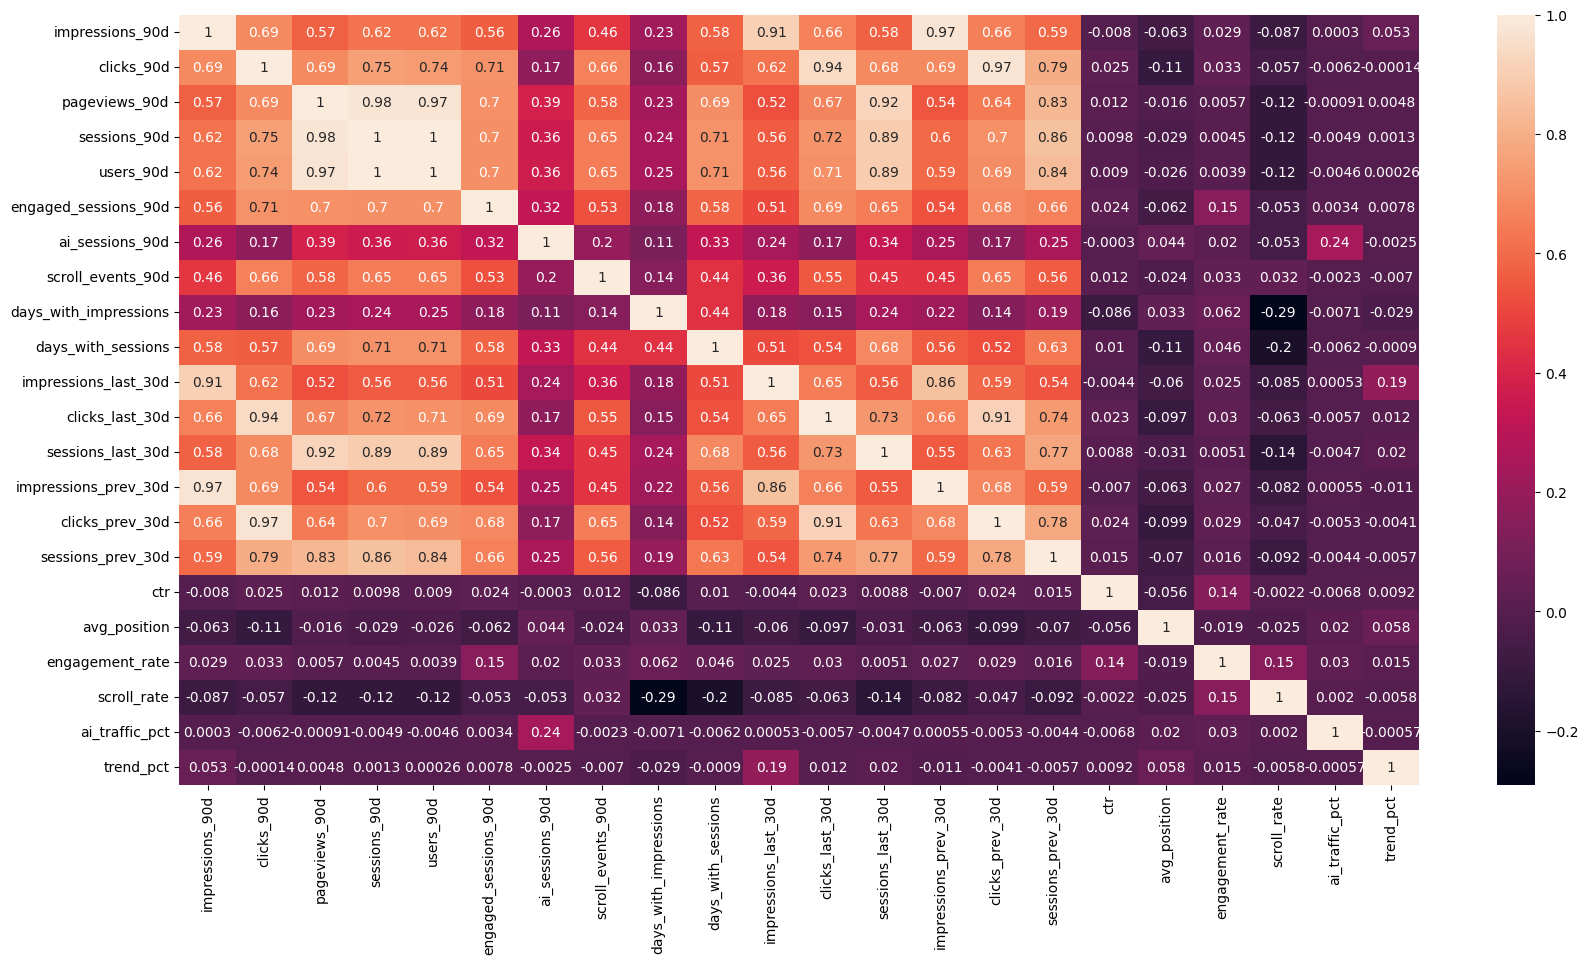

In [33]:
plt.figure(figsize = (20,10))
sns.heatmap(performance_data.corr(), annot = True)
plt.show()

In [34]:
for i in performance_data.columns:
  if '30d' in i:
    performance_data = performance_data.drop(columns = [i], axis = 1)
performance_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   impressions_90d        17235 non-null  int64  
 1   clicks_90d             17235 non-null  int64  
 2   pageviews_90d          17235 non-null  int64  
 3   sessions_90d           17235 non-null  int64  
 4   users_90d              17235 non-null  int64  
 5   engaged_sessions_90d   17235 non-null  int64  
 6   ai_sessions_90d        17235 non-null  int64  
 7   scroll_events_90d      17235 non-null  int64  
 8   days_with_impressions  17235 non-null  int64  
 9   days_with_sessions     17235 non-null  int64  
 10  ctr                    17235 non-null  float64
 11  avg_position           17235 non-null  float64
 12  engagement_rate        17235 non-null  float64
 13  scroll_rate            17123 non-null  float64
 14  ai_traffic_pct         17235 non-null  float64
 15  trend_p

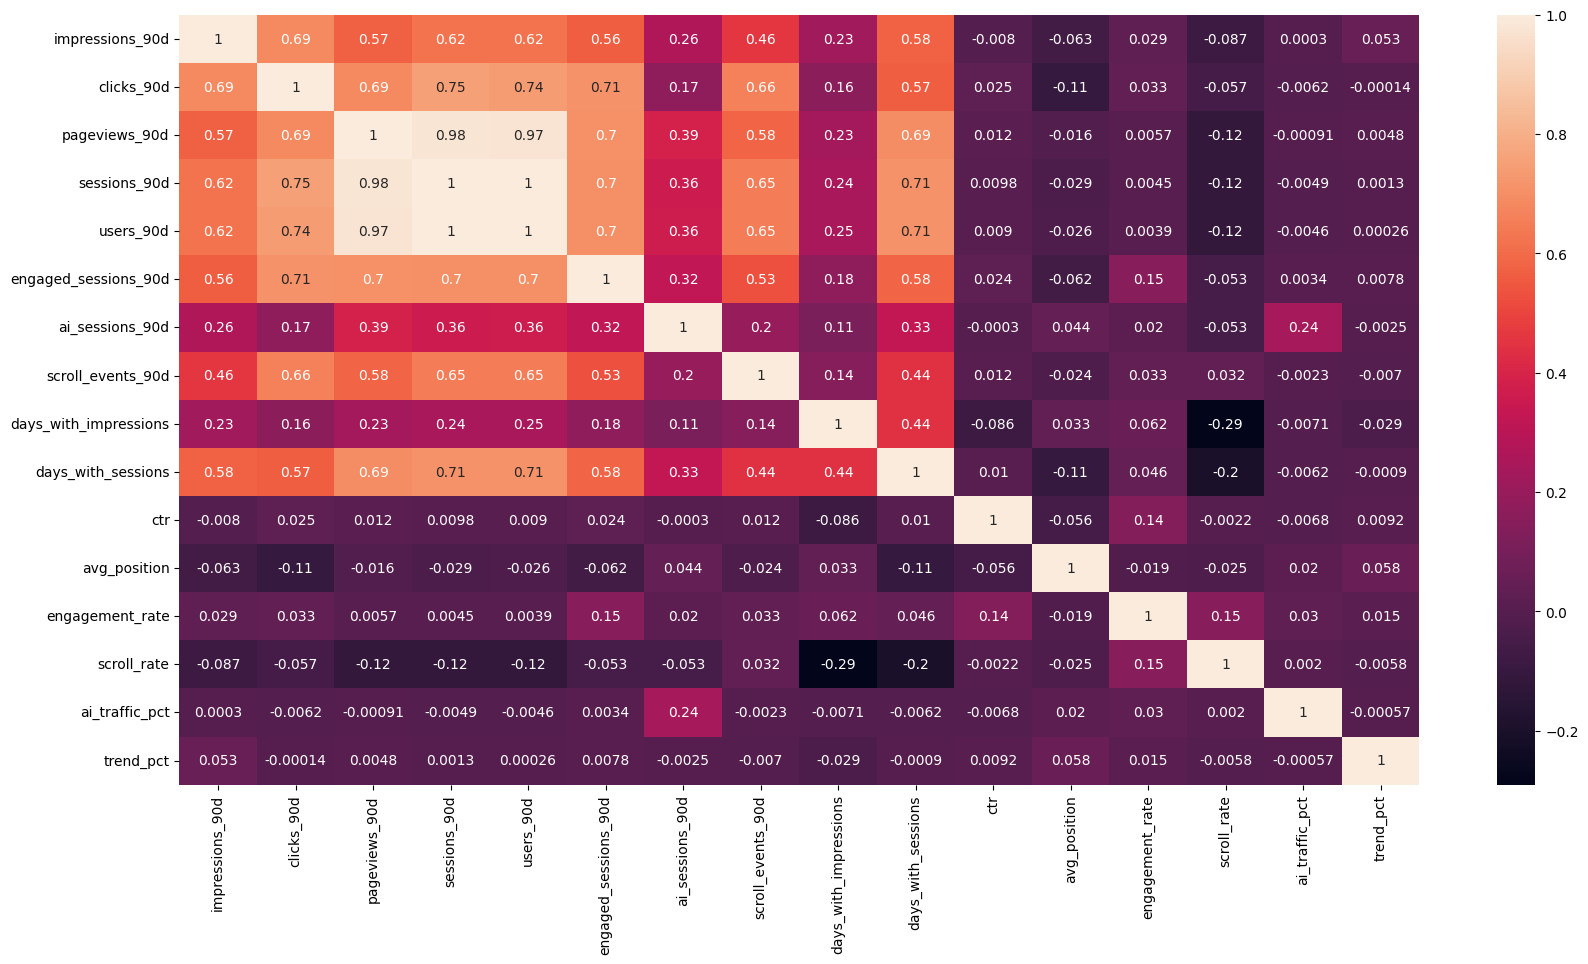

In [35]:
plt.figure(figsize = (20,10))
sns.heatmap(performance_data.corr(), annot = True)
plt.show()

In [37]:
performance_data = performance_data.drop(columns = ['sessions_90d', 'users_90d'], axis = 1)


KeyError: "['sessions_90d', 'users_90d'] not found in axis"

In [48]:
performance_data.describe()

,impressions_90d,clicks_90d,pageviews_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17235.000000,17123.000000,17235.000000,16006.000000
mean,5463.726139,15.846475,53.350972,0.997505,0.202611,4.253728,64.587990,13.533101,0.351973,17.285825,2.466381,18.347572,0.610308,-7.807641
std,17474.806144,71.502667,158.190241,3.883179,1.264775,17.434443,30.589908,17.547571,2.415805,15.019713,7.936736,30.264874,6.720703,384.726815
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,122.000000,0.000000,3.000000,0.000000,0.000000,0.000000,43.000000,2.000000,0.000000,6.900000,0.000000,0.000000,0.000000,-62.600000
50%,848.000000,1.000000,9.000000,0.000000,0.000000,1.000000,83.000000,6.000000,0.070000,11.900000,0.000000,5.000000,0.000000,-34.000000
75%,3966.000000,7.000000,37.000000,1.000000,0.000000,3.000000,88.000000,17.000000,0.270000,23.550000,1.450000,25.000000,0.000000,0.000000
max,517715.000000,2689.000000,5998.000000,142.000000,46.000000,1156.000000,88.000000,90.000000,100.000000,161.000000,100.000000,300.000000,300.000000,27907.300000


In [44]:

final_columns = list(performance_data)
content_data_columns = ['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used','content_age_days',
       'days_since_last_update']
final_columns = content_data_columns + final_columns
final_columns

['content_id',
 'client_id',
 'search_volume',
 'competition',
 'competition_level',
 'cpc',
 'content_type',
 'main_intent',
 'word_count',
 'char_count',
 'provider_used',
 'model_used',
 'content_age_days',
 'days_since_last_update',
 'impressions_90d',
 'clicks_90d',
 'pageviews_90d',
 'engaged_sessions_90d',
 'ai_sessions_90d',
 'scroll_events_90d',
 'days_with_impressions',
 'days_with_sessions',
 'ctr',
 'avg_position',
 'engagement_rate',
 'scroll_rate',
 'ai_traffic_pct',
 'trend_pct']

In [45]:
final_data = info_data[final_columns].copy()
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              17235 non-null  object 
 1   client_id               17235 non-null  object 
 2   search_volume           17092 non-null  float64
 3   competition             17092 non-null  float64
 4   competition_level       17092 non-null  object 
 5   cpc                     17092 non-null  float64
 6   content_type            17235 non-null  object 
 7   main_intent             17235 non-null  object 
 8   word_count              13169 non-null  float64
 9   char_count              13169 non-null  float64
 10  provider_used           5399 non-null   object 
 11  model_used              14443 non-null  object 
 12  content_age_days        17235 non-null  int64  
 13  days_since_last_update  17235 non-null  int64  
 14  impressions_90d         17235 non-null  int

In [53]:
final_data['avg_position'] = final_data['avg_position'].replace(0, pd.NA)
final_data['avg_position'].sample(10)

,avg_position
21711,40.1
717,26.1
15581,4.1
22220,6.7
13418,9.1
9742,7.8
10467,20.7
65,5.8
4607,6.6
18667,7.7


In [49]:
performance_data.columns

Index(['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct'],
      dtype='object')

In [55]:
higher = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct']
lower = ['avg_position']

for i in higher:
  name = i + '_rank'
  final_data[name] = final_data[i].rank(pct = True)

for j in lower:
  name = j + '_rank'
  final_data[name] = (-final_data[j]).rank(pct = True)

final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17235 entries, 1 to 29996
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   content_id                  17235 non-null  object 
 1   client_id                   17235 non-null  object 
 2   search_volume               17092 non-null  float64
 3   competition                 17092 non-null  float64
 4   competition_level           17092 non-null  object 
 5   cpc                         17092 non-null  float64
 6   content_type                17235 non-null  object 
 7   main_intent                 17235 non-null  object 
 8   word_count                  13169 non-null  float64
 9   char_count                  13169 non-null  float64
 10  provider_used               5399 non-null   object 
 11  model_used                  14443 non-null  object 
 12  content_age_days            17235 non-null  int64  
 13  days_since_last_update      17235 no

In [56]:
final_data.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,trend_pct_rank,avg_position_rank
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.468059,0.488019,0.809370,0.602785,0.468755,0.356948,0.612860,0.468059,0.291453,0.307948
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.468059,0.795997,0.809370,0.650218,0.527444,0.356948,0.779332,0.468059,0.264776,0.108826
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.468059,0.986017,0.809370,0.875573,0.587525,0.356948,0.745197,0.468059,0.494752,0.068849
6,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,0.468059,0.183638,0.127038,0.078271,0.214070,0.356948,0.184839,0.468059,0.065569,0.752740
8,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,0.468059,0.882768,0.502118,0.920279,0.527444,0.885263,0.537231,0.468059,0.282363,0.060953


In [62]:
perfomance_metrics = []
for i in final_data.columns:
  if 'rank' in i:
    perfomance_metrics.append(i)

final_data['performance_score'] = final_data[perfomance_metrics].sum(axis = 1) * 100 / len(perfomance_metrics)
final_data.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,trend_pct_rank,avg_position_rank,performance_score
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.488019,0.809370,0.602785,0.468755,0.356948,0.612860,0.468059,0.291453,0.307948,53.005026
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.795997,0.809370,0.650218,0.527444,0.356948,0.779332,0.468059,0.264776,0.108826,56.159524
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.986017,0.809370,0.875573,0.587525,0.356948,0.745197,0.468059,0.494752,0.068849,63.934734
6,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,0.183638,0.127038,0.078271,0.214070,0.356948,0.184839,0.468059,0.065569,0.752740,26.228918
8,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,0.882768,0.502118,0.920279,0.527444,0.885263,0.537231,0.468059,0.282363,0.060953,65.907300


In [63]:
final_data['performance_score'].describe()

,performance_score
count,17235.000000
mean,49.670521
std,16.380500
min,18.803598
25%,36.574226
50%,47.615899
75%,62.218043
max,92.045649


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.